https://github.com/anitapathak/ML_lab_And_Assignment.git/

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


## ***Read the file***

In [7]:
df = pd.read_csv("/content/behavioral_indicators_internal_marks(1).csv")


***Data cleaning Process using mean replacment method ***




In [8]:
# 1. Remove duplicates
df = df.drop_duplicates()

# 2. Convert numeric columns safely
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

# 3. Fill missing values with column mean (only numeric)
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].mean(), inplace=True)

print("Data cleaned successfully")
print(df.isnull().sum())

Data cleaned successfully
CRN                         0
Theory_Attendance_Pct       0
Assignment_Unit_I           0
Assignment_Unit_II          0
Assignment_Unit_III         0
Assignment_PU_6_Set         0
Lab_Attendance_Pct          0
Lab_Report_1a               0
Lab_Report_1b               0
ML_on_Git                   0
Viva_Marks                  0
Final_Theory_Marks_30       0
Final_Practical_Marks_20    0
Total_Internal_Marks_50     0
dtype: int64


/tmp/ipykernel_7512/1386113157.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/tmp/ipykernel_7512/1386113157.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CRN                       96 non-null     object 
 1   Theory_Attendance_Pct     96 non-null     float64
 2   Assignment_Unit_I         96 non-null     float64
 3   Assignment_Unit_II        96 non-null     float64
 4   Assignment_Unit_III       96 non-null     float64
 5   Assignment_PU_6_Set       96 non-null     int64  
 6   Lab_Attendance_Pct        96 non-null     float64
 7   Lab_Report_1a             96 non-null     float64
 8   Lab_Report_1b             96 non-null     float64
 9   ML_on_Git                 96 non-null     int64  
 10  Viva_Marks                96 non-null     float64
 11  Final_Theory_Marks_30     96 non-null     float64
 12  Final_Practical_Marks_20  96 non-null     float64
 13  Total_Internal_Marks_50   96 non-null     float64
dtypes: float64(1

***finding corretion on different datasets and arranging the data***

In [10]:
target = "Total_Internal_Marks_50"

# Correlation with target
corr = df.corr(numeric_only=True)[target]

# Remove target itself and sort ascending
corr_sorted = corr.drop(target).sort_values(ascending=True)

print("Correlation with", target)
print(corr_sorted)


Correlation with Total_Internal_Marks_50
Assignment_Unit_III         0.528287
Assignment_Unit_II          0.590173
Lab_Report_1a               0.738189
Assignment_Unit_I           0.742707
Lab_Report_1b               0.748589
Viva_Marks                  0.831081
ML_on_Git                   0.832419
Assignment_PU_6_Set         0.833763
Theory_Attendance_Pct       0.863205
Lab_Attendance_Pct          0.872387
Final_Practical_Marks_20    0.962881
Final_Theory_Marks_30       0.969016
Name: Total_Internal_Marks_50, dtype: float64


# Select features (X) and target (Y)

In [11]:

X = df[[
    "Lab_Attendance_Pct",
    "Theory_Attendance_Pct",
    "Assignment_PU_6_Set"

]]

Y = df["Total_Internal_Marks_50"]

***Plot the boxplot to see outliers ***

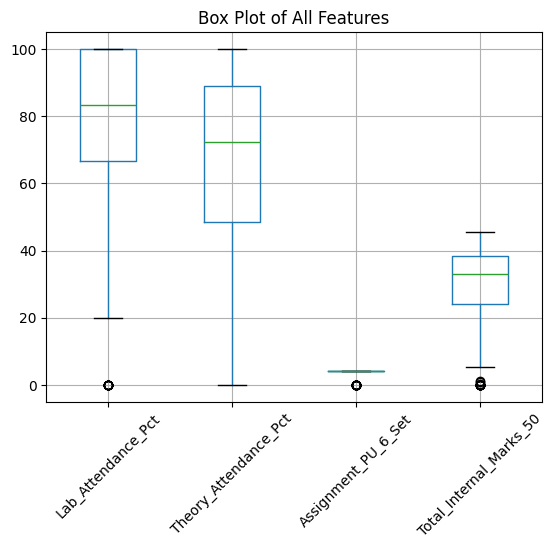

In [12]:
df[[
    "Lab_Attendance_Pct",
    "Theory_Attendance_Pct",
    "Assignment_PU_6_Set",
    "Total_Internal_Marks_50"
]].boxplot()
plt.xticks(rotation=45)
plt.title("Box Plot of All Features")
plt.show()

***Handling outliers***

In [13]:
cols = [
    "Lab_Attendance_Pct",
    "Theory_Attendance_Pct",
    "Assignment_PU_6_Set",
    "Total_Internal_Marks_50"
]

df_clean = df.copy()

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

***fit model to linear regression***

In [14]:
import pandas as pd
from sklearn.linear_model import LinearRegression


# Create model
model = LinearRegression()

# Fit model
model.fit(X, Y)

# Print coefficients
print("Intercept (a0):", model.intercept_)

print("\nCoefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(name, ":", coef)


# Prediction
Y_pred = model.predict(X)

print("\nFirst 5 Predictions:")
print(Y_pred[:5])


Intercept (a0): 0.17785697350103646

Coefficients:
Lab_Attendance_Pct : 0.12189049390839721
Theory_Attendance_Pct : 0.1509456102137336
Assignment_PU_6_Set : 3.1566950049893685

First 5 Predictions:
[23.55036381 30.10315702 36.73390051 33.37955362 30.10315702]


***finding the equation of y=a0+a1x1+a2X2+a3X3***

In [15]:
a0 = model.intercept_

# Coefficients
coeffs = model.coef_

# Start equation string
equation = f"y = {a0:.4f}"

for name, coef in zip(X.columns, coeffs):
    equation += f" + ({coef:.4f})*{name}"

print("\nRegression Equation:")
print(equation)


Regression Equation:
y = 0.1779 + (0.1219)*Lab_Attendance_Pct + (0.1509)*Theory_Attendance_Pct + (3.1567)*Assignment_PU_6_Set


***error finding using the absolute error and mean absolute error and R-squared  method***

In [16]:
# Predictions
Y_pred = model.predict(X)

# 1. Absolute Error (per sample)
absolute_error = abs(Y - Y_pred)

print("First 10 Absolute Errors:")
print(absolute_error[:10])

# 2. Mean Absolute Error (overall)
mae = mean_absolute_error(Y, Y_pred)
print("\nMean Absolute Error (MAE):", mae)

# 3. R-Square (R² Score)
r2 = r2_score(Y, Y_pred)
print("\nR-Square (R² Score):", r2)

First 10 Absolute Errors:
0    2.290364
1    8.404843
2    3.625901
3    3.252446
4    1.452843
5    1.415667
6    6.413909
7    1.999074
8    5.690014
9    4.046410
Name: Total_Internal_Marks_50, dtype: float64

Mean Absolute Error (MAE): 3.5529096334909505

R-Square (R² Score): 0.8882872599544762


***plot the linear graph ***

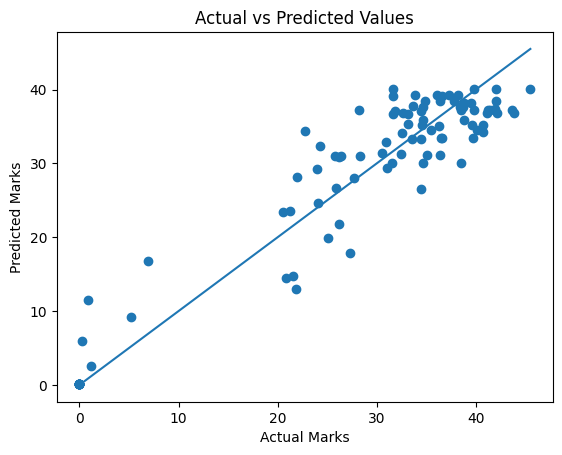

In [17]:
Y_pred = model.predict(X)

plt.figure()
plt.scatter(Y, Y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Values")

# ideal line (perfect prediction)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()])
plt.show()


*** Residual Plot (Error Distribution)***
  Random scatter around 0 → good model
  Pattern → model is biased or wrong ***bold text***

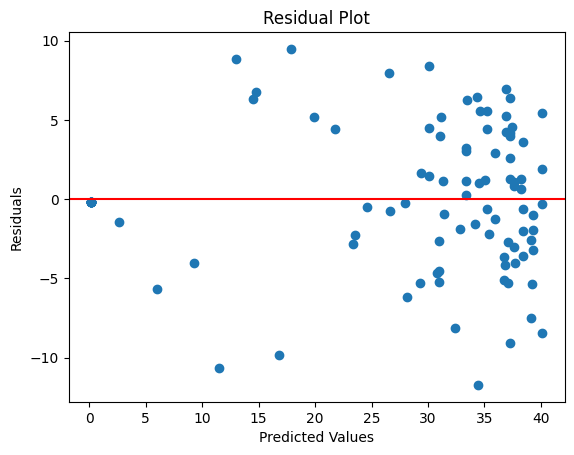

In [18]:
residuals = Y - Y_pred

plt.figure()
plt.scatter(Y_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

***Histogram of Errors***

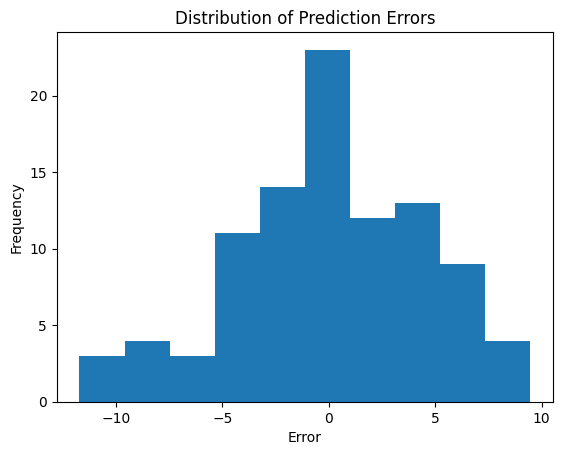

In [19]:

plt.figure()
plt.hist(residuals, bins=10)
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()
